<a href="https://colab.research.google.com/github/FreddieLewin23/FreddieLewin23/blob/main/Lotech_data_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

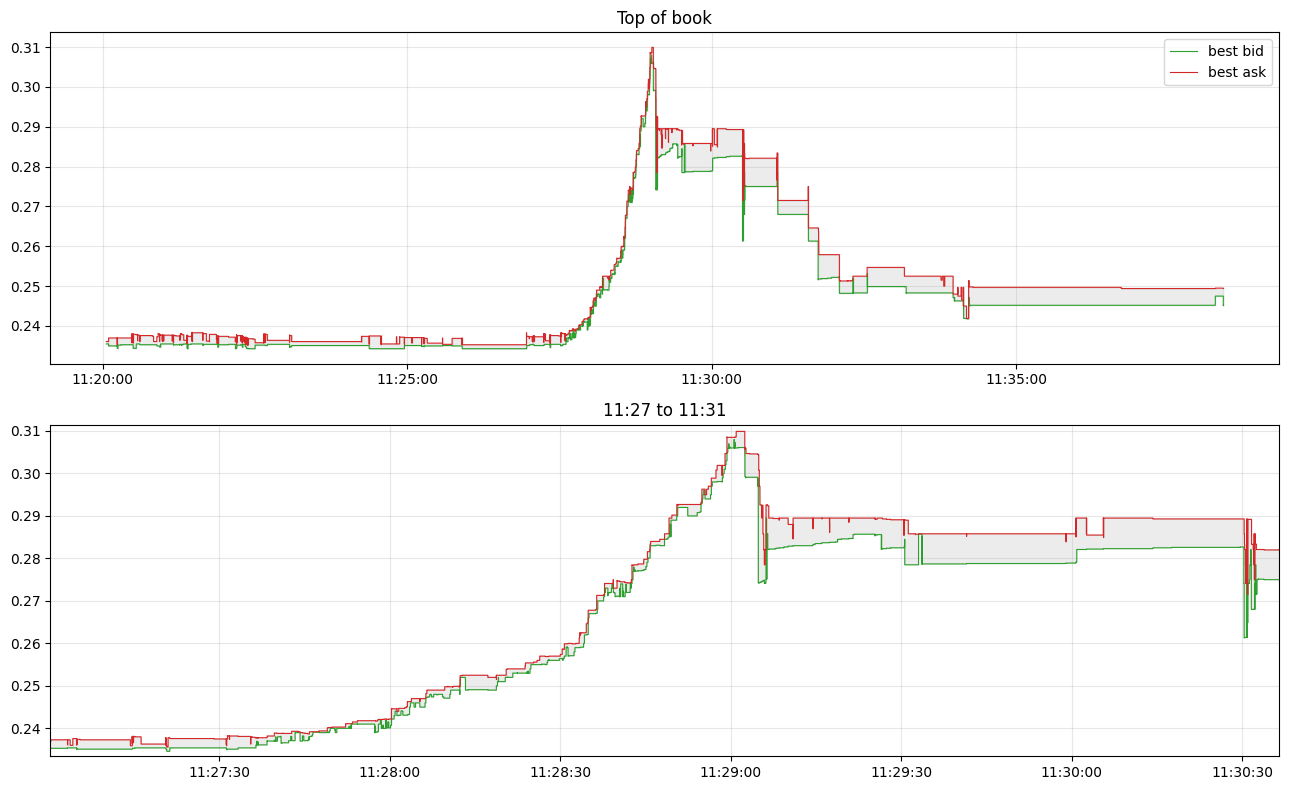

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tob = pd.read_csv(U + 'top_of_book.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts')

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8))

for ax in (a1, a2):
    ax.step(tob.transaction_ts, tob.bid_price, where='post', lw=0.8, color='tab:green', label='best bid')
    ax.step(tob.transaction_ts, tob.ask_price, where='post', lw=0.8, color='tab:red', label='best ask')
    ax.fill_between(tob.transaction_ts, tob.bid_price, tob.ask_price, step='post', alpha=0.15, color='grey')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.grid(True, alpha=0.3)

a1.set_title('Top of book')
a1.legend()

zoom = tob[(tob.transaction_ts >= '2025-04-27 11:27:00') & (tob.transaction_ts <= '2025-04-27 11:31:00')]
a2.set_xlim(zoom.transaction_ts.min(), zoom.transaction_ts.max())
a2.set_ylim(zoom.bid_price.min() * 0.995, zoom.ask_price.max() * 1.005)
a2.set_title('11:27 to 11:31')

plt.tight_layout()
plt.show()

Interaction between public and private trades
Cells P1-P4. Assumes G1's frames are not loaded, so it reloads.

ASSUMPTIONS made in this section, restate them in your report:
1.  private_trades.csv is the complete fill record (34 rows)
2.  public feed excludes our own fills (verified in G3, zero time/price/qty matches) so public side = other people's aggressor flow and our participation is
ours / (ours + public)
3.  clocks across files agree to well under 1s, unverified, all +/- alignment
below inherits this
4. public 'side' is the aggressor side
5. absence of private fills before 11:27:35 is real, not truncation. P1 verifies
     this from the logs, which cover 11:20 onward and show fill events


In [4]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (13, 5)

U = ''  # your data directory
tob = pd.read_csv(U + 'top_of_book.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts').reset_index(drop=True)
pub = pd.read_csv(U + 'public_trades.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts').reset_index(drop=True)
priv = pd.read_csv(U + 'private_trades.csv', parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
tob['mid'] = (tob.bid_price + tob.ask_price) / 2

# verify from logs: any nonzero fill events before the first private trade?
fill_pat = re.compile(r'^(\S+ \S+).*filled ([0-9.]+)@([0-9.]+)')
log_fills = []
with open(U + 'logs.txt') as f:
    for line in f:
        m = fill_pat.match(line)
        if m and float(m.group(2)) > 0:
            log_fills.append(pd.Timestamp(m.group(1)))
log_fills = pd.Series(sorted(set(log_fills)))
print('first fill event in logs:', log_fills.min())
print('first private trade:     ', priv.timestamp.min())
print('log fill events before first private trade:',
      int((log_fills < priv.timestamp.min()).sum()))
# if zero: the algo quoted from 11:20 with NO fills for ~7.5 minutes, then all 34
# fills arrive inside the 2 minute move. fill arrival is entirely concentrated in
# the toxic window, that is the headline of the public/private interaction.

first fill event in logs: 2025-04-27 11:27:35.538298019
first private trade:      2025-04-27 11:27:35.535490048
log fill events before first private trade: 0


In [5]:
# for each private fill: signed public taker flow in the 5s before and 5s after
pub['signed'] = pub.qty.where(pub.side == 'Buy', -pub.qty)

def flow(t0, t1):
    m = (pub.transaction_ts >= t0) & (pub.transaction_ts < t1)
    return pub.loc[m, 'signed'].sum()

rows = []
for _, f in priv.iterrows():
    rows.append(dict(t=f.timestamp, side=f.side, price=f.price, qty=f.qty,
                     flow_pre_5s=flow(f.timestamp - pd.Timedelta('5s'), f.timestamp),
                     flow_post_5s=flow(f.timestamp, f.timestamp + pd.Timedelta('5s'))))
inter = pd.DataFrame(rows)
print('mean signed public flow around our fills (positive = net aggressor buying):')
print(inter.groupby('side')[['flow_pre_5s', 'flow_post_5s']].mean().round(1))
# read: SELL rows with big positive flow_pre = our offers were consumed inside
# aggressive buy bursts. BUY rows with negative flow_pre or flow_post = someone
# dumped into our bids, look especially at the largest fills near the top.
print('\nlargest 5 fills with their surrounding flow:')
print(inter.nlargest(5, 'qty').to_string(index=False))

mean signed public flow around our fills (positive = net aggressor buying):
      flow_pre_5s  flow_post_5s
side                           
BUY          71.4         312.7
SELL        218.2         376.0

largest 5 fills with their surrounding flow:
                            t side  price     qty  flow_pre_5s  flow_post_5s
2025-04-27 11:29:02.457684992  BUY 0.2993 9038.53      -184.97       -302.83
2025-04-27 11:29:02.457668096  BUY 0.3014  964.82      -184.97       -302.83
2025-04-27 11:29:30.466705152 SELL 0.2854  493.02         0.00         20.91
2025-04-27 11:28:38.374288128  BUY 0.2712  174.14       669.66       -205.51
2025-04-27 11:28:52.421449984  BUY 0.2902  109.54       109.98        279.81


In [6]:
priv['ms_group'] = priv.timestamp.dt.floor('ms')
same_ms = priv.groupby('ms_group').filter(lambda g: len(g) > 1)
print('fills sharing the same millisecond:')
print(same_ms[['timestamp', 'side', 'price', 'qty', 'exchange_order_id']].to_string(index=False))
# simultaneous fills at different prices = the market sweeping through several of
# our layered quotes in one shot, note when these happen relative to the top

dup_oid = priv[priv.duplicated('exchange_order_id', keep=False)]
print('\nsame order filled more than once:')
print(dup_oid[['timestamp', 'side', 'price', 'qty', 'exchange_order_id']].to_string(index=False))

tiny = priv[priv.qty <= 0.1]
print('\nresidual dust fills (qty <= 0.1):')
print(tiny[['timestamp', 'side', 'price', 'qty']].to_string(index=False))

fills sharing the same millisecond:
                    timestamp side  price     qty  exchange_order_id
2025-04-27 11:29:02.457639936  BUY 0.3058    9.82       828977435103
2025-04-27 11:29:02.457668096  BUY 0.3014  964.82       828977430144
2025-04-27 11:29:02.457684992  BUY 0.2993 9038.53       828977435113
2025-04-27 11:29:05.909607936  BUY 0.2744   10.94       828977459706
2025-04-27 11:29:05.909625088  BUY 0.2744   10.94       828977459746
2025-04-27 11:29:30.600777984  BUY 0.2826   10.62       828977554501
2025-04-27 11:29:30.600798208  BUY 0.2826   10.62       828977561760
2025-04-27 11:29:30.600808192  BUY 0.2810   10.68       828977576308
2025-04-27 11:29:30.600829952  BUY 0.2793   49.18       828977561786

same order filled more than once:
                    timestamp side  price   qty  exchange_order_id
2025-04-27 11:27:42.550287104 SELL 0.2388 42.08       828977024450
2025-04-27 11:27:42.750388992 SELL 0.2390  0.01       828977024450
2025-04-27 11:28:20.492658944 SELL 0.2

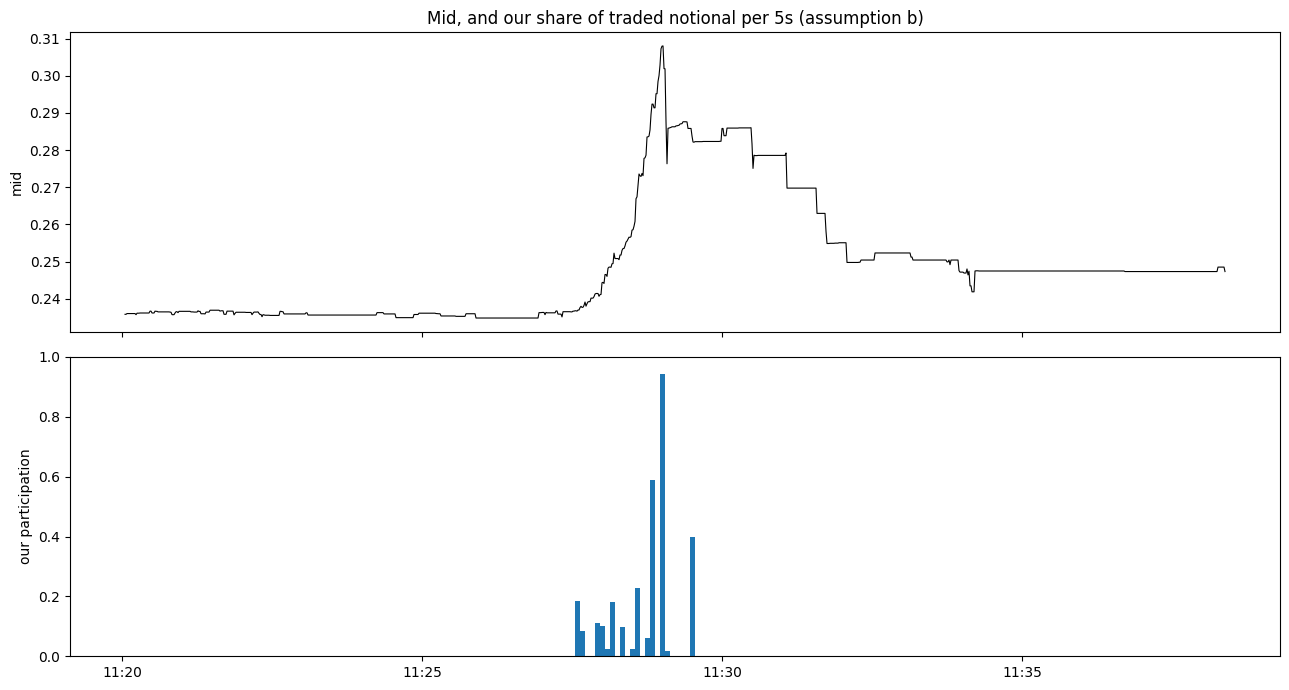

In [9]:
b = '5s'
ours = priv.set_index('timestamp').qty.mul(priv.set_index('timestamp').price).resample(b).sum()
theirs = pub.set_index('transaction_ts').assign(n=lambda d: d.qty * d.price).n.resample(b).sum()
part = (ours / (ours + theirs)).fillna(0)

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 7))
mid_s = tob.set_index('transaction_ts').mid.resample('1s').last().ffill()
a1.plot(mid_s.index, mid_s.values, lw=0.8, color='k')
a1.set_ylabel('mid')
a1.set_title('Mid, and our share of traded notional per 5s (assumption b)')
a2.bar(part.index, part.values, width=pd.Timedelta(b) / pd.Timedelta('1D'), color='tab:blue')
a2.set_ylabel('our participation')
a2.set_ylim(0, 1)
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()
# spikes toward 1 mean intervals where almost all volume was people trading
# against us specifically, worth cross-referencing with the largest fills in P2

okay so what do we actually see here.

**The 11:29:02.457 millisecond is the main period of trading**. Three of the layered bids at 0.3058, 0.3014, 0.2993 were swept top down in a single millisecond (blast trade) for around 3k USD notional and what was the peak of the spot. Net public flow was -185 pre trade and -303 post trade. So someone sold 10k to Lo-tech and the public book barely shifted (you would expect some slippage down for this size on this shallow of an order book). The sellers aggression against us you cant see on the public trades so any algo trying to detect this toxic flow would need to consume the private trades.

**The sells on way up are the opposite** SELL row shows +218 mean flow in the 5s before and +376 after (ie lo techs offers were consumer inside aggressive buy bursts and buying continued after each one, so every sell marked out negatively. Sold cheap into the rally and bought size at the top (adversely selected in both direction).

**The 11:29:30 rows look like a second sweep**. Four bids from 0.2826 down to 0.2793 taken in 1 millisecond. and 134ms before that 493 unit sell at 0.2854 with almost no public flow around it. the 0.2826 apir and earlier 10.94 pair at 11:29:05 are same price and same millisecond but with different order ids. it looks like the algo runs at least two orders per side at the same time, which matches the other wave spoken about above.

the double order fill ..227176 is tow partial fills 158ms apart summing to 69.57 which in the log files says 69.57@0.2539 (this agrees, good, but is split in the trades .csv files).






Infer the algo's behaviour
Cell A: quoted size through time and where the big bids sat
Cell B: fair value vs market, was the model calling those bids cheap
ASSUMPTIONS for this section:
1.  orders.csv rows are state intervals of resting orders, total resting size at
2. time t = sum of available_qty over rows whose (opening_time, closing_time)
contains t. rows with null closing_time treated as open until file end
3. a handful of rows have negative available_qty, dropped and counted below,
cause unknown, one for the assumptions list
4. timestamps in orders.csv are rounded to whole seconds, so sizes around the fast sweeps are accurate to ~1s only

negative qty rows dropped: 4


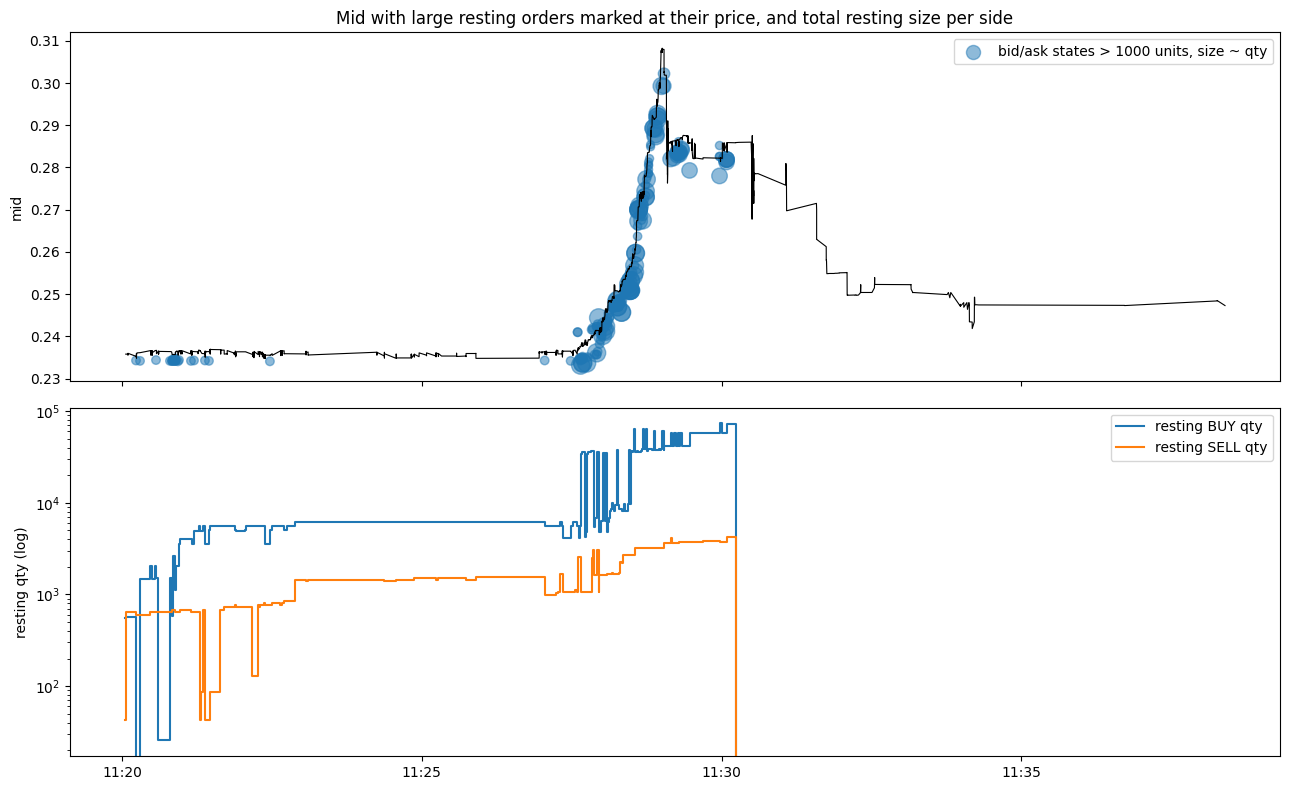


largest 10 resting states, distance from mid at open (negative = below mid):
       opening_time        closing_time side  price  available_qty  dist_pct
2025-04-27 11:27:39 2025-04-27 11:27:41  BUY   0.23       29638.74     -1.85
2025-04-27 11:27:41 2025-04-27 11:27:41  BUY   0.23       29638.74     -1.66
2025-04-27 11:27:41 2025-04-27 11:27:43  BUY   0.23       29638.74     -1.66
2025-04-27 11:27:45 2025-04-27 11:27:52  BUY   0.23       29479.79     -1.81
2025-04-27 11:27:55 2025-04-27 11:27:57  BUY   0.24       29188.54     -2.20
2025-04-27 11:27:57 2025-04-27 11:27:57 SELL   0.24       29155.90      1.24
2025-04-27 11:28:01 2025-04-27 11:28:02  BUY   0.24       28806.05     -1.68
2025-04-27 11:28:02 2025-04-27 11:28:03  BUY   0.24       28806.05     -1.23
2025-04-27 11:28:04 2025-04-27 11:28:04  BUY   0.24       28588.32     -2.15
2025-04-27 11:28:04 2025-04-27 11:28:05  BUY   0.24       28588.32     -1.66

state history of order 828977435113 (the 9k fill):
                 openin

In [11]:
plt.rcParams['figure.figsize'] = (13, 5)

tob = pd.read_csv(U + 'top_of_book.csv', parse_dates=['transaction_ts']).sort_values('transaction_ts').reset_index(drop=True)
orders = pd.read_csv(U + 'orders.csv', parse_dates=['opening_time', 'closing_time'])
tob['mid'] = (tob.bid_price + tob.ask_price) / 2
tob_idx = tob.set_index('transaction_ts')

neg = (orders.available_qty < 0).sum()
print('negative qty rows dropped:', neg)
orders = orders[orders.available_qty >= 0].copy()
orders['end'] = orders.closing_time.fillna(orders.closing_time.max())

# event-based resting size
ev = pd.concat([
    pd.DataFrame({'t': orders.opening_time, 'side': orders.side, 'dq': orders.available_qty}),
    pd.DataFrame({'t': orders.end, 'side': orders.side, 'dq': -orders.available_qty})
]).sort_values('t')
rest = ev.pivot_table(index='t', columns='side', values='dq', aggfunc='sum').fillna(0).cumsum()

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 8))
a1.plot(tob.transaction_ts, tob.mid, lw=0.8, color='k')
a1.set_ylabel('mid')
big = orders[orders.available_qty > 1000]
mid_at_open = tob_idx.mid.reindex(big.opening_time, method='ffill').values
a1.scatter(big.opening_time, big.price, s=np.sqrt(big.available_qty), c='tab:blue', alpha=0.5,
           label='bid/ask states > 1000 units, size ~ qty')
a1.legend()
a1.set_title('Mid with large resting orders marked at their price, and total resting size per side')
a2.step(rest.index, rest.get('BUY', 0), where='post', color='tab:blue', label='resting BUY qty')
a2.step(rest.index, rest.get('SELL', 0), where='post', color='tab:orange', label='resting SELL qty')
a2.set_yscale('log'); a2.set_ylabel('resting qty (log)')
a2.legend()
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

big = big.copy()
big['mid_at_open'] = mid_at_open
big['dist_pct'] = (big.price / big.mid_at_open - 1) * 100
print('\nlargest 10 resting states, distance from mid at open (negative = below mid):')
cols = ['opening_time', 'closing_time', 'side', 'price', 'available_qty', 'dist_pct']
print(big.nlargest(10, 'available_qty')[cols].round(2).to_string(index=False))
# things to read off: are there two size regimes (small near-touch quotes vs a
# giant deep layer), when did the giant bids appear, how far below mid did they
# sit, and did that distance protect them when the dump came

# life of the order that ate the 9038 sweep
print('\nstate history of order 828977435113 (the 9k fill):')
print(orders[orders.exchange_order_id == 828977435113][cols[:5]].to_string(index=False))

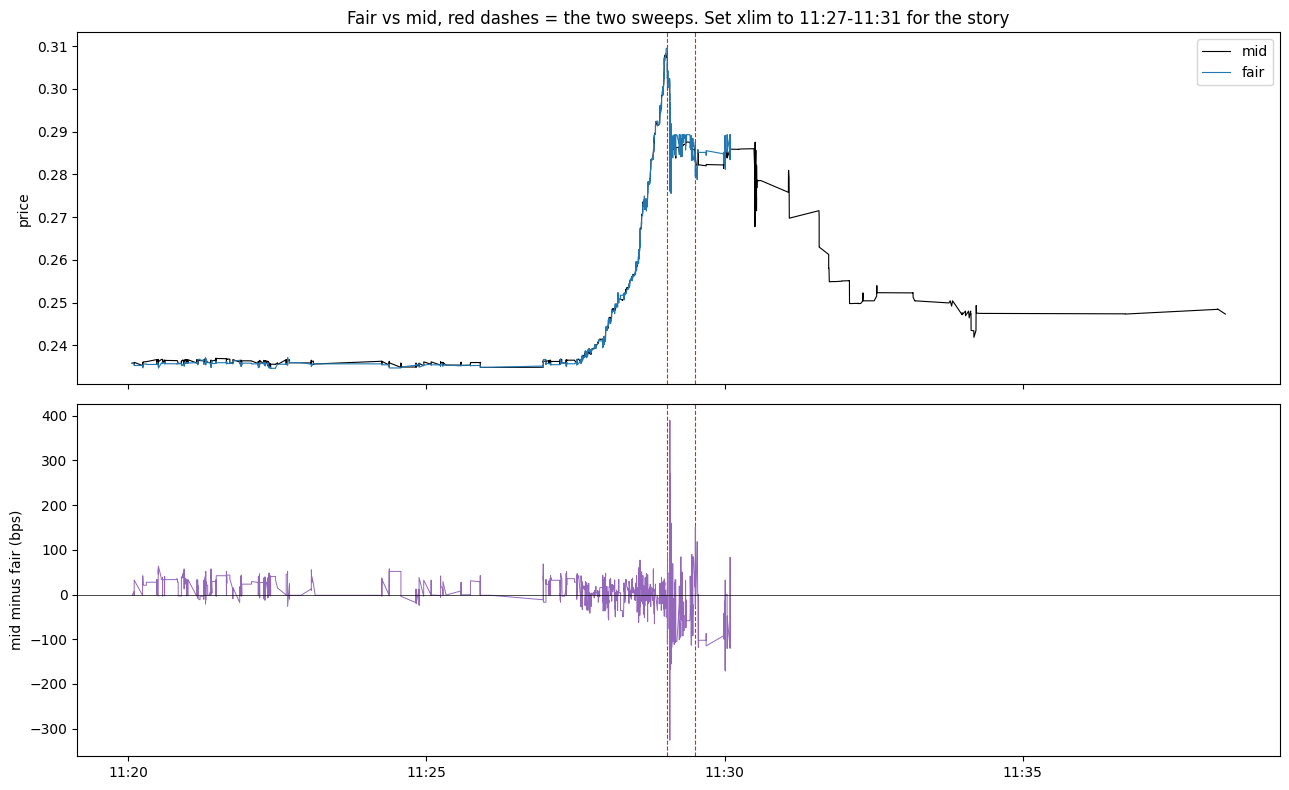

around 11:29:02.457000: fair min 0.2759 max 0.3095, lag bps min -326 max 390
around 11:29:30.600000: fair min 0.2788 max 0.2884, lag bps min -92 max 151


In [12]:
pat = re.compile(r'^(\S+ \S+).*?fair: ([0-9.]+);')
rows = []
with open(U + 'logs.txt') as f:
    for line in f:
        m = pat.match(line)
        if m:
            rows.append((m.group(1), float(m.group(2))))
fair = pd.DataFrame(rows, columns=['ts', 'fair']).drop_duplicates('ts')
fair['ts'] = pd.to_datetime(fair.ts)
fair = fair.sort_values('ts').reset_index(drop=True)
fair['mid'] = tob_idx.mid.reindex(fair.ts, method='ffill').values
fair['lag_bps'] = (fair.mid - fair.fair) / fair.mid * 1e4

sweeps = [pd.Timestamp('2025-04-27 11:29:02.457'), pd.Timestamp('2025-04-27 11:29:30.600')]

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 8))
a1.plot(tob.transaction_ts, tob.mid, lw=0.8, color='k', label='mid')
a1.plot(fair.ts, fair.fair, lw=0.8, color='tab:blue', label='fair')
for s in sweeps:
    a1.axvline(s, color='tab:red', lw=0.8, ls='--')
    a2.axvline(s, color='tab:red', lw=0.8, ls='--')
a1.legend(); a1.set_ylabel('price')
a1.set_title('Fair vs mid, red dashes = the two sweeps. Set xlim to 11:27-11:31 for the story')
a2.plot(fair.ts, fair.lag_bps, lw=0.7, color='tab:purple')
a2.axhline(0, color='k', lw=0.5)
a2.set_ylabel('mid minus fair (bps)')
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

for s in sweeps:
    w = fair[(fair.ts >= s - pd.Timedelta('3s')) & (fair.ts <= s + pd.Timedelta('3s'))]
    if len(w):
        print(f'around {s.time()}: fair min {w.fair.min():.4f} max {w.fair.max():.4f}, '
              f'lag bps min {w.lag_bps.min():.0f} max {w.lag_bps.max():.0f}')

1. The algo fair is very close to market mid throughout. through the big increase the two are almost identical and mid minus fair is only far away in the chaoctic seconds at the top of the increase. This suggests to me the algo fair is derived from the book (some sort of order book weighted mid price maybe) rather than something more derived (like a black scholes for an option). so a one sided taken driven move drags fair with it and the allowed quoting ranges follow. A FV that follows price doesnt give you any resistance to bid increases or deceased.

2. the quoting is strcutured as a small near-touch quote plus a deeper quote. It is bid skewed throughout, resting buy quantity runs 4-10 times the sell quantity. there was 29k units sitting around 2% until under mid. I am not sure this is a great idea as the sizing does not shrink as vol increases, which is something you would want in any size edge curve in markets I have traded on in the past.

in the log files we have token LO, venue LOEXCHANGE, account lowobservabletech and strategy module mmaas (market making as a service). I am unsure what the contracts look like for market making as a service so perhaps there are some rules about pulling bids or withdrawing size when flow looks toxic. so i think taking this as an assumption is important going forward.

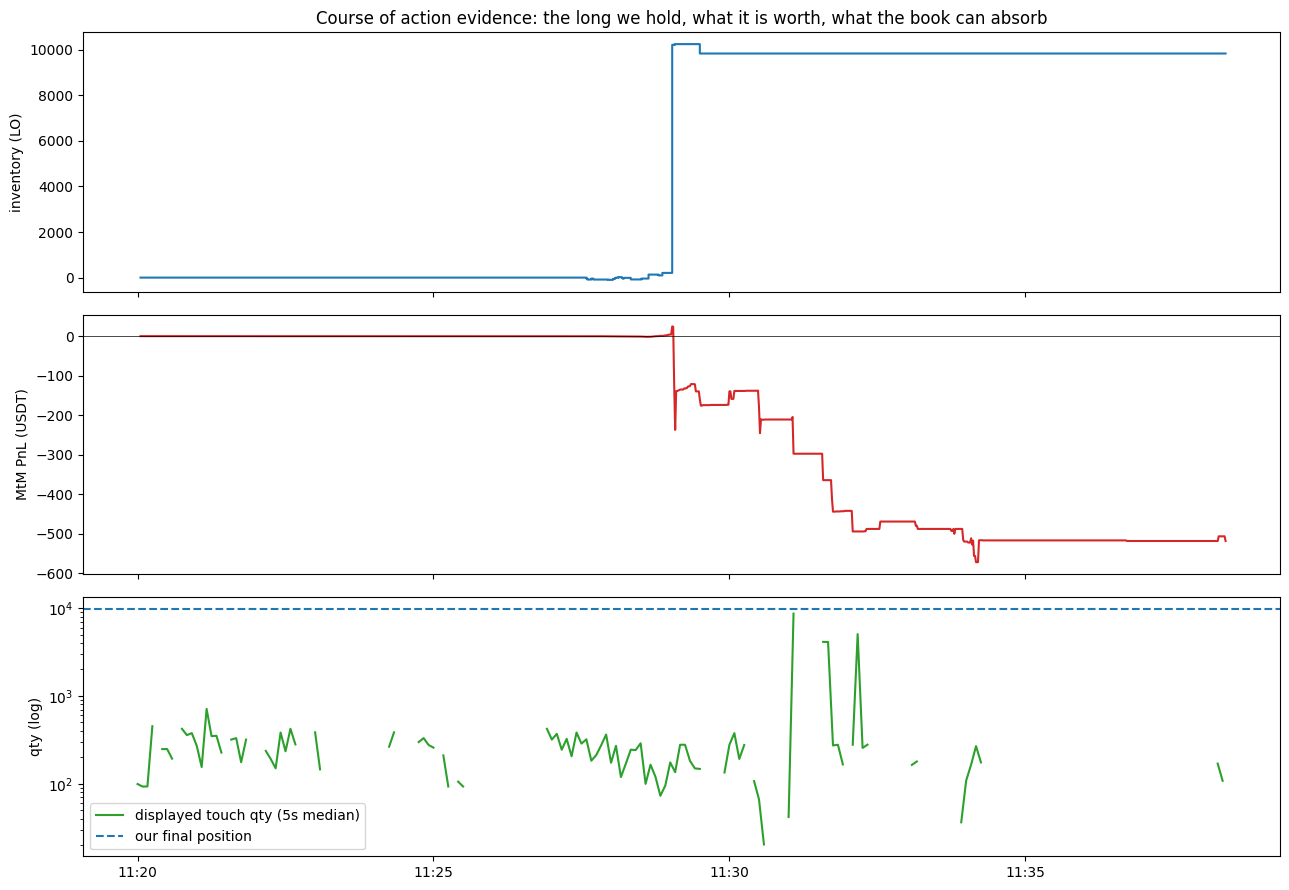

final position: 9832.4 LO | final MtM: -518.16 USDT
median displayed touch qty: 241.8 => position is 41.0 x the touch


In [14]:
p = priv.copy()
p['signed_qty'] = p.qty.where(p.side == 'BUY', -p.qty)
p['lo_fee'] = np.where(p.fee_ccy == 'LO', p.fee, 0.0)
p['usdt_fee'] = np.where(p.fee_ccy == 'USDT', p.fee, 0.0)
p['inv'] = (p.signed_qty - p.lo_fee).cumsum()
p['cash'] = (-p.signed_qty * p.price - p.usdt_fee).cumsum()
mid_s = tob_idx.mid.resample('1s').last().ffill()
inv_s = p.set_index('timestamp').inv.resample('1s').last().reindex(mid_s.index).ffill().fillna(0)
cash_s = p.set_index('timestamp').cash.resample('1s').last().reindex(mid_s.index).ffill().fillna(0)
mtm = cash_s + inv_s * mid_s

fig, (a1, a2, a3) = plt.subplots(3, 1, sharex=True, figsize=(13, 9))
a1.step(inv_s.index, inv_s.values, where='post', color='tab:blue')
a1.set_ylabel('inventory (LO)')
a1.set_title('Course of action evidence: the long we hold, what it is worth, what the book can absorb')
a2.plot(mtm.index, mtm.values, color='tab:red')
a2.axhline(0, color='k', lw=0.5)
a2.set_ylabel('MtM PnL (USDT)')
touch = (tob.set_index('transaction_ts')[['bid_qty', 'ask_qty']].sum(axis=1)).resample('5s').median()
a3.plot(touch.index, touch.values, color='tab:green', label='displayed touch qty (5s median)')
a3.axhline(inv_s.iloc[-1], color='tab:blue', ls='--', label='our final position')
a3.set_yscale('log'); a3.set_ylabel('qty (log)'); a3.legend()
a3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()
print('final position:', round(inv_s.iloc[-1], 1), 'LO | final MtM:', round(mtm.iloc[-1], 2), 'USDT')
print('median displayed touch qty:', round(touch.median(), 1),
      '=> position is', round(inv_s.iloc[-1] / touch.median(), 0), 'x the touch')

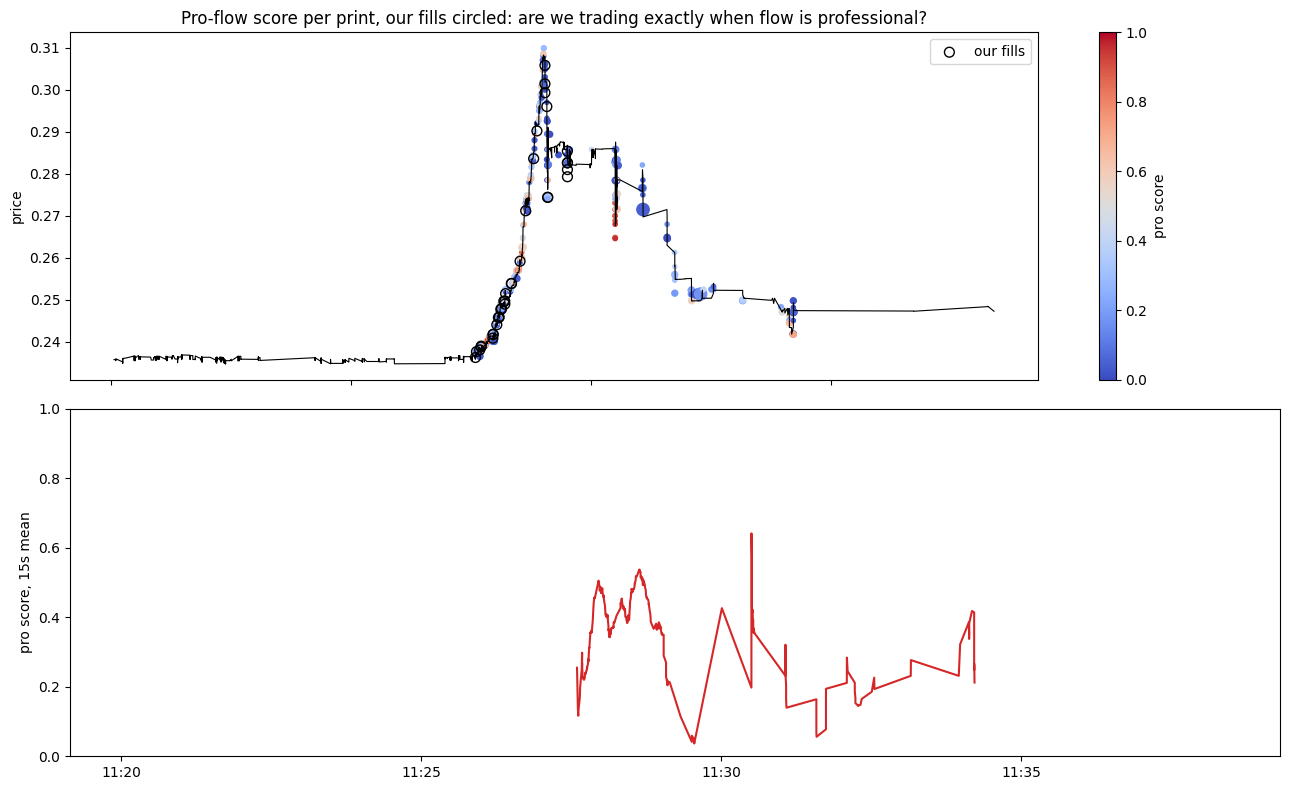

mean pro score overall: 0.35
mean pro score at our fill times: 0.31


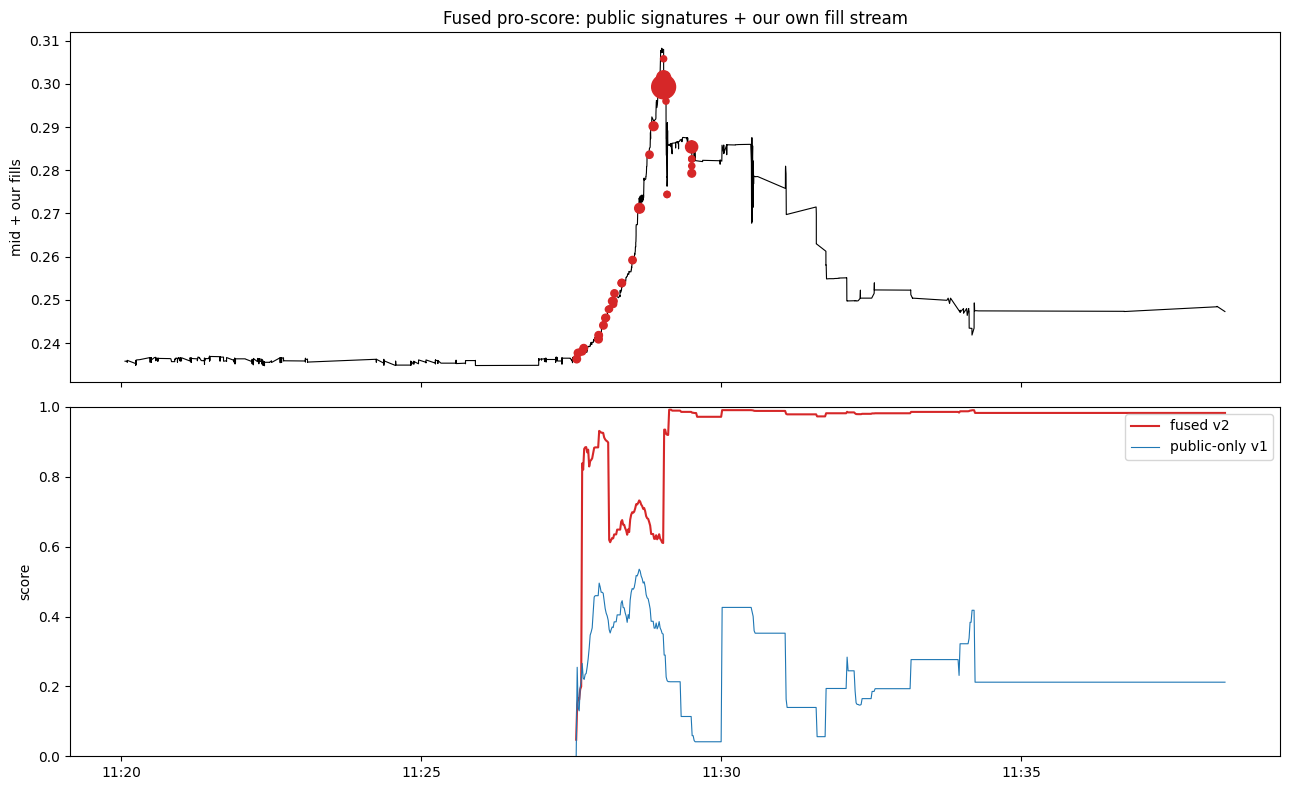

30s before the 11:29:02 sweep: v1 0.48  fused 0.70
at the 11:29:02 sweep: v1 0.35  fused 0.61
calm baseline 11:27:40: v1 0.21  fused 0.20


In [16]:
# No labels exist in this data, so this is a composite of mechanical signatures of
# professional execution, squashed to [0,1]. Weights and scales are hand-set and
# marked for tuning, calibration would need labelled or longer history.
# Signatures used, all causal (trailing windows only):
#  s1 clip repetition: same rounded qty seen in the trailing 10s (slicers repeat clips)
#  s2 arrival regularity: low coefficient of variation of the last 5 inter-arrival
#     times (machines are metronomic, humans are bursty-random)
#  s3 one-sidedness: |signed| / total qty over trailing 30s
#  s4 impact: signed mid move over the trailing 10s, informed flow moves price
#  s5 sweep: multiple prints inside 50ms (single taker walking levels)
pub['signed'] = pub.qty.where(pub.side == 'Buy', -pub.qty)
pub['qty_r'] = pub.qty.round(1)
pub['dt'] = pub.transaction_ts.diff().dt.total_seconds()

mid_ser = tob_idx.mid[~tob_idx.index.duplicated(keep='last')]
t = pub.transaction_ts

s1 = np.zeros(len(pub)); s2 = np.zeros(len(pub)); s5 = np.zeros(len(pub))
for i in range(len(pub)):
    w = pub[(t >= t.iloc[i] - pd.Timedelta('10s')) & (t < t.iloc[i])]
    s1[i] = (w.qty_r == pub.qty_r.iloc[i]).sum()
    dts = pub.dt.iloc[max(0, i - 4):i + 1].dropna()
    if len(dts) >= 3 and dts.mean() > 0:
        cv = dts.std() / dts.mean()
        s2[i] = max(0.0, 1.0 - cv)
    s5[i] = ((t >= t.iloc[i] - pd.Timedelta('50ms')) & (t < t.iloc[i])).sum()

flow30 = pub.set_index('transaction_ts').signed.rolling('30s').sum().values
tot30 = pub.set_index('transaction_ts').qty.rolling('30s').sum().values
s3 = np.abs(flow30) / np.maximum(tot30, 1e-9)
mid_now = mid_ser.reindex(t, method='ffill').values
mid_10 = mid_ser.reindex(t - pd.Timedelta('10s'), method='ffill').values
s4 = np.sign(pub.signed.values) * (mid_now - mid_10) / mid_now * 1e4

z = (0.6 * np.minimum(s1 / 5, 1)      # tune: 5 repeats saturates
     + 0.8 * s2
     + 0.8 * s3
     + 0.5 * np.clip(s4 / 100, -1, 1)  # tune: 100bps trailing impact saturates
     + 0.6 * np.minimum(s5 / 3, 1))    # tune: 3 prints in 50ms saturates
pub['pro_score'] = 1 / (1 + np.exp(-(z - 1.2) * 3))  # tune: center and slope

score_s = pub.set_index('transaction_ts').pro_score.rolling('15s').mean()

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 8))
a1.plot(tob.transaction_ts, tob.mid, lw=0.8, color='k')
sc = a1.scatter(pub.transaction_ts, pub.price, c=pub.pro_score, cmap='coolwarm',
                s=6 + np.sqrt(pub.qty), vmin=0, vmax=1)
plt.colorbar(sc, ax=a1, label='pro score')
a1.scatter(priv.timestamp, priv.price, s=50, facecolors='none', edgecolors='k', lw=1, label='our fills')
a1.legend(); a1.set_ylabel('price')
a1.set_title('Pro-flow score per print, our fills circled: are we trading exactly when flow is professional?')
a2.plot(score_s.index, score_s.values, color='tab:red')
a2.set_ylabel('pro score, 15s mean'); a2.set_ylim(0, 1)
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

fills_score = score_s[~score_s.index.duplicated(keep='last')].reindex(priv.timestamp, method='ffill')
print('mean pro score overall:', round(pub.pro_score.mean(), 2))
print('mean pro score at our fill times:', round(fills_score.mean(), 2))
# if the second number is materially higher, the score is doing its job: our fills
# arrive when flow is professional, and gating quote size on it would have cut the
# damage. caveats for the report: heuristic weights, public feed excludes our own
# fills so the score is blind to flow aimed only at us (the 11:29:02 sweep), and
# with prints starting mid-rise there is no calm baseline to calibrate against.




# R3's caveat is structural: our own fills do not print publicly, so a score built
# on public prints is blind to the professional trading against us specifically.
# v2 adds features only we can see, all causal:
#  p1 own-fill intensity: notional filled against us in the trailing 30s
#  p2 own sweep: >1 of our orders filled inside 50ms (someone walking our levels)
#  p3 own markout: mean signed 5s markout of our fills evaluated 5s later
grid = pd.date_range(pub.transaction_ts.min().floor('s'),
                     tob.transaction_ts.max().ceil('s'), freq='1s')

pf = priv.set_index('timestamp').sort_index()
pf_notional = (pf.qty * pf.price)
p1 = pf_notional.rolling('30s').sum().reindex(grid, method='ffill').fillna(0)

same_50ms = (pf.index.to_series().diff() <= pd.Timedelta('50ms'))
p2 = same_50ms.astype(float).rolling('30s').max().reindex(grid, method='ffill').fillna(0)

sgn = np.where(pf.side == 'BUY', 1, -1)
m_now = mid_ser.reindex(pf.index, method='ffill').values
m_5 = mid_ser.reindex(pf.index + pd.Timedelta('5s'), method='ffill').values
mo = pd.Series(sgn * (m_5 - pf.price.values) / pf.price.values * 1e4, index=pf.index + pd.Timedelta('5s'))
p3 = mo.rolling('60s').mean().reindex(grid, method='ffill').fillna(0)

pub_score_1s = pub.set_index('transaction_ts').pro_score.rolling('15s').mean()
pub_score_1s = pub_score_1s[~pub_score_1s.index.duplicated(keep='last')].reindex(grid, method='ffill').fillna(0)

z2 = (1.0 * pub_score_1s
      + 0.8 * np.minimum(p1 / 50, 1)          # tune: 50 USDT/30s of own fills saturates
      + 0.8 * p2
      + 0.8 * np.clip(-p3 / 30, 0, 1))        # tune: -30bps own markout saturates
fused = 1 / (1 + np.exp(-(z2 - 1.0) * 3))     # tune

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(13, 8))
a1.plot(tob.transaction_ts, tob.mid, lw=0.8, color='k')
a1.scatter(priv.timestamp, priv.price, s=10 + np.sqrt(priv.qty) * 3, c='tab:red', zorder=5)
a1.set_ylabel('mid + our fills')
a1.set_title('Fused pro-score: public signatures + our own fill stream')
a2.plot(grid, fused.values, color='tab:red', label='fused v2')
a2.plot(grid, pub_score_1s.values, color='tab:blue', lw=0.8, label='public-only v1')
a2.set_ylim(0, 1); a2.set_ylabel('score'); a2.legend()
a2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout(); plt.show()

for label, ts in [('30s before the 11:29:02 sweep', pd.Timestamp('2025-04-27 11:28:32')),
                  ('at the 11:29:02 sweep', pd.Timestamp('2025-04-27 11:29:02')),
                  ('calm baseline 11:27:40', pd.Timestamp('2025-04-27 11:27:40'))]:
    i = grid.searchsorted(ts)
    if 0 <= i < len(grid):
        print(f'{label}: v1 {pub_score_1s.iloc[i]:.2f}  fused {fused.iloc[i]:.2f}')
# the question for your report: was the fused score already elevated BEFORE the
# 9k sweep, i.e. would gating quote size on it have pulled the deep bid in time

Toxicity score ideas:
The idea is a causal score in [0,1] estimating the probability that the current flow is professiobal so quoting can be gated on it continuously rather than reacting after losses. Version 1 uses the public prints only: clip size repetition, flow one sidedness, trailing impact and sub 50ms swep gate. It fails. Mainly, I think, due to professional trading occuring in the private trades. Version2 two therefore combines tthe data courses, own fill intensity, multi order sweeps (features can be seen above). On this event the v2 score read 0.7 thirty seconds before the 9k sweep while the public only version read 0.48 so a size gate at 0.6 would have cut the deep bid before it was hit. This is hard to say whether it would generalise as I would need far more data, but I think it is a good idea regardless. Weights in the flow score are hard coded and hand set, uncalibrated and this is a one sample event.

Recommended changes:
1. The losses are due to four main design problems. FV is derived from the market itself, so a one sided move drags it along and it rated top tick bids as cheap: need to anchor the FV to a slower reference and discount moves driven by one-directional taker flow (maybe link it so a large coin or some maths like black scholes or a jump diffusion model to value the coin but I have not done enough crypto to understand whether these ideas are feasible or even coherent).

2. Size ignores toxicity. all 34 fills arrived in a 2 minute window after 7.5 minutes of no fills so maybe a gate quote size on fill rate spikes (anti blast trades) as well as flow one sidedness.

3. there was also 29k bid down 2% after a 27% move just a few minutes ago. This feels wrong to me. When volatility is this high charging only 2% of edge from fair is practically nothing and any edge you charge will eaten away by spot moves in a lot of cases. the sizing's could have a realised vol factor that increases quoting width proportional to the RV in the previous few minutes or hours.

4. there were rate limits when it needed to requote. 302 discards and 155 rate limits queue eents in the 11:28 minute against low single digits in calm. I am unsure of the exact mechanics here about what casuses the rate limit to be triggered as well as the discards. I would need more information to answer this the best I can.

COURSE OF ACTION:
We end the window with 9,832 long LO within 2% of the top marked at -518USDT. More inforamtion that would be useful is whether the deeper bids are able to be viewed by the market as a whole (or only the top of book).




